# Inverse propensity weighting (DoWhy backdoor.propensity_score_weighting)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from dowhy import CausalModel
from xgboost import XGBClassifier


## Define mRS outcome target and cutoff for early treatment

In [2]:
MRS_TARGET = 2  # Model will set y as being less than or equal to this value

CUTOFF = 270


## Define adjustment fields

In [3]:
NON_CATEGORICAL_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'year',
    'onset_to_scan_time'
]

CATEGORICAL_FEATURES = [
    'stroke_team',
    'ethnicity',
    'treatment_group'
]

# W features are the covariates used to predict treatment assignment (propensity score)

W_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'ethnicity',
    'stroke_team',
    'year',
    'onset_to_scan_time'
]

TREATMENTS = [
    'onset_to_thrombolysis_time',
    'onset_to_thrombectomy_time',
]

cf_features = list(set(W_FEATURES + TREATMENTS))
descriptive_features = list(set(NON_CATEGORICAL_FEATURES + CATEGORICAL_FEATURES))


## Load and filter data

In [4]:
data = pd.read_csv("../../data/sam3/cleaned_data.csv", low_memory=False)

# Calculate onset_to_scan
data["onset_to_scan_time"] = data["onset_to_arrival_time"] - data["arrival_to_scan_time"]

print(f"Initial data shape: {data.shape}")

# Remove rows with missing discharge disability
data = data.dropna(subset=["discharge_disability"])

# Keep only infarction cases
data = data[data["infarction"] == 1]

# Keep only onset to arrival < 360 mins
data = data[data["onset_to_arrival_time"] < 360]

# Keep only perfusion_imaging_used == 0
data = data[data["perfusion_imaging_used"] == 0]

# Limit to stroke severity > 5
data = data[((data["stroke_severity"] > 5) | data["lvo"] == 1)]

# Keep only teams with at least 10 onset_to_thrombectomy_time
team_counts = data.groupby("stroke_team")["onset_to_thrombectomy_time"].count()
valid_teams = team_counts[team_counts >= 10].index
data = data[data["stroke_team"].isin(valid_teams)]

# Missing treatment times -> sentinel
data["onset_to_thrombolysis_time"] = data["onset_to_thrombolysis_time"].fillna(99999)
data["onset_to_thrombectomy_time"] = data["onset_to_thrombectomy_time"].fillna(99999)

# Remove rows where thrombolysis is after thrombectomy (if both are present)
both_treatments = (
    (data["onset_to_thrombolysis_time"] < 99999)
    & (data["onset_to_thrombectomy_time"] < 99999)
)
thrombolysis_after_thrombectomy = (
    data["onset_to_thrombolysis_time"] > data["onset_to_thrombectomy_time"]
)
data = data[~(both_treatments & thrombolysis_after_thrombectomy)]

# Exclude late thrombectomy (> 720) unless sentinel
data = data[
    (data["onset_to_thrombectomy_time"] < 720)
    | (data["onset_to_thrombectomy_time"] == 99999)
]

# Exclude late thrombolysis (> 360) unless sentinel
data = data[
    (data["onset_to_thrombolysis_time"] < 360)
    | (data["onset_to_thrombolysis_time"] == 99999)
]

# Restrict data to cf_features, and keep only complete rows
data = data[cf_features + ["discharge_disability"]].dropna()

print(f"Final data shape: {data.shape}")


Initial data shape: (452863, 71)
Final data shape: (59516, 15)


## Add treatment groups and outcome

In [5]:
TIME_THROMBOLYSIS = "onset_to_thrombolysis_time"
TIME_THROMBECTOMY = "onset_to_thrombectomy_time"

def add_treatment_columns(data):
    """
    Add treatment column based on use and time of thrombolysis/thrombectomy.
    Use CUTOFF to determine whether treatment is early or late.
    Sentinel value of 99999 means no treatment.
    """
    data["treatment_group"] = "neither"
    data.loc[(data[TIME_THROMBOLYSIS] <= CUTOFF) & (data[TIME_THROMBECTOMY] == 99999),
             "treatment_group"] = "early_thrombolysis_only"
    data.loc[(data[TIME_THROMBOLYSIS] > CUTOFF) & (data[TIME_THROMBOLYSIS] != 99999) &
             (data[TIME_THROMBECTOMY] == 99999),
             "treatment_group"] = "late_thrombolysis_only"
    data.loc[(data[TIME_THROMBOLYSIS] == 99999) & (data[TIME_THROMBECTOMY] < CUTOFF),
             "treatment_group"] = "early_thrombectomy_only"
    data.loc[(data[TIME_THROMBOLYSIS] == 99999) & (data[TIME_THROMBECTOMY] >= CUTOFF) &
             (data[TIME_THROMBECTOMY] != 99999),
             "treatment_group"] = "late_thrombectomy_only"
    data.loc[(data[TIME_THROMBOLYSIS] <= CUTOFF) & (data[TIME_THROMBECTOMY] < CUTOFF),
             "treatment_group"] = "early_both"
    data.loc[(data[TIME_THROMBOLYSIS] <= CUTOFF) & (data[TIME_THROMBECTOMY] >= CUTOFF) &
             (data[TIME_THROMBECTOMY] != 99999),
             "treatment_group"] = "early_thrombolysis_late_thrombectomy"
    data.loc[(data[TIME_THROMBOLYSIS] > CUTOFF) & (data[TIME_THROMBOLYSIS] != 99999) &
             (data[TIME_THROMBECTOMY] > CUTOFF) & (data[TIME_THROMBECTOMY] != 99999),
             "treatment_group"] = "late_both"
    return data

data = add_treatment_columns(data)

# Binary good-outcome target: mRS <= MRS_TARGET
data["good_outcome"] = (data["discharge_disability"] <= MRS_TARGET).astype(int)

REFERENCE_GROUP = "neither"
TREATMENT_GROUPS = [g for g in data["treatment_group"].unique() if g != REFERENCE_GROUP]
print(TREATMENT_GROUPS)


['early_thrombolysis_only', 'late_thrombolysis_only', 'early_thrombectomy_only', 'early_both', 'early_thrombolysis_late_thrombectomy', 'late_thrombectomy_only', 'late_both']


## Fit DoWhy causal model per treatment group vs reference
For each non-reference `treatment_group` level, fit a `CausalModel` against the `neither` group, identify the backdoor set from `W_FEATURES`, and estimate the effect using `backdoor.propensity_score_weighting`. Propensity scores and IPW weights are extracted directly from the fitted DoWhy estimator.

In [6]:
USE_XGBOOST_PROPENSITY = True  # set False to use DoWhy's default LogisticRegression
TARGET_UNITS = "att"  # ATT: effect for patients who actually received the treatment

def make_propensity_model():
    if USE_XGBOOST_PROPENSITY:
        return XGBClassifier(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            use_label_encoder=False,
        )
    return None  # DoWhy defaults to LogisticRegression when None


def fit_dowhy_ipw(data, treatment_group_value, reference=REFERENCE_GROUP,
                   w_features=W_FEATURES, outcome_col="good_outcome",
                   target_units=TARGET_UNITS):
    """Fit a DoWhy CausalModel comparing one treatment_group level against
    the reference group, using backdoor.propensity_score_weighting.
    Propensity can be estimated with XGBoost (USE_XGBOOST_PROPENSITY=True)
    or DoWhy's default logistic regression. Returns the subset dataframe
    (with propensity_score / ipw_weight columns, taken directly from DoWhy's
    internal model data) and the CausalEstimate."""

    subset = data[data["treatment_group"].isin([treatment_group_value, reference])].copy()
    subset["treatment"] = (subset["treatment_group"] == treatment_group_value).astype(int)

    model = CausalModel(
        data=subset,
        treatment="treatment",
        outcome=outcome_col,
        common_causes=w_features,
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)

    method_params = {"weighting_scheme": "ips_weight"}
    propensity_model = make_propensity_model()
    if propensity_model is not None:
        method_params["propensity_score_model"] = propensity_model

    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.propensity_score_weighting",
        target_units=target_units,
        method_params=method_params,
    )

    # DoWhy stores the fitted propensity score and IPW weight columns
    # directly in model._data after estimate_effect() is called.
    fitted_data = model._data

    subset = subset.reset_index(drop=True)
    subset["propensity_score"] = fitted_data["propensity_score"].values
    subset["ipw_weight"] = fitted_data["ips_weight"].values

    return subset, estimate


results = {}
estimates = {}

for group in TREATMENT_GROUPS:
    subset, estimate = fit_dowhy_ipw(data, group)
    results[group] = subset
    estimates[group] = estimate
    print(f"{group}: {TARGET_UNITS.upper()} = {estimate.value:.4f}")


early_thrombolysis_only: ATT = 0.1070
late_thrombolysis_only: ATT = 0.1334
early_thrombectomy_only: ATT = 0.1004
early_both: ATT = 0.1660
early_thrombolysis_late_thrombectomy: ATT = 0.1492
late_thrombectomy_only: ATT = 0.0865
late_both: ATT = 0.1737


## Weight diagnostics (max weight, % extreme weights, effective sample size)

In [7]:
diagnostic_rows = []

for group, subset in results.items():
    w = subset["ipw_weight"]
    n = len(w)
    max_weight = w.max()
    pct_weight_gt_10 = (w > 10).mean() * 100
    ess = (w.sum() ** 2) / (w ** 2).sum()
    ess_pct_of_n = ess / n * 100
    diagnostic_rows.append({
        "treatment_group": group,
        "n": n,
        "max_weight": round(max_weight, 2),
        "pct_weight_gt_10": round(pct_weight_gt_10, 2),
        "effective_sample_size": round(ess, 2),
        "ess_pct_of_n": round(ess_pct_of_n, 2),
    })

diagnostics_df = pd.DataFrame(diagnostic_rows).set_index("treatment_group")
diagnostics_df


,n,max_weight,pct_weight_gt_10,effective_sample_size,ess_pct_of_n
treatment_group,,,,,
early_thrombolysis_only,53935,20.0,0.46,36222.68,67.16
late_thrombolysis_only,31850,20.0,1.41,9754.38,30.63
early_thrombectomy_only,32083,20.0,0.92,12164.85,37.92
early_both,33447,20.0,0.64,15812.50,47.28
early_thrombolysis_late_thrombectomy,31103,20.0,0.54,14044.68,45.16
late_thrombectomy_only,31403,20.0,0.82,11930.96,37.99
late_both,30957,20.0,0.18,20912.43,67.55


## Treatment effect (ATE) by group

In [14]:
ate_rows = []

for group, estimate in estimates.items():
    ate = estimate.value
    try:
        ci_lower, ci_upper = estimate.get_confidence_intervals()
    except Exception:
        ci_lower, ci_upper = np.nan, np.nan
    n_treated = (results[group]["treatment"] == 1).sum()
    ate_rows.append({
        "treatment_group": group,
        "ate": ate,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "count": n_treated,
    })

ate_df = pd.DataFrame(ate_rows).set_index("treatment_group")
cate_summary = ate_df.copy()
ate_df


,ate,ci_lower,ci_upper,count
treatment_group,,,,
early_thrombolysis_only,0.106970,0.096665,0.117515,23058
late_thrombolysis_only,0.133423,0.100290,0.163804,973
early_thrombectomy_only,0.100351,0.071840,0.126068,1206
early_both,0.165978,0.142606,0.187590,2570
early_thrombolysis_late_thrombectomy,0.149156,0.084051,0.208141,226
late_thrombectomy_only,0.086470,0.040124,0.130119,526
late_both,0.173668,0.071812,0.283726,80


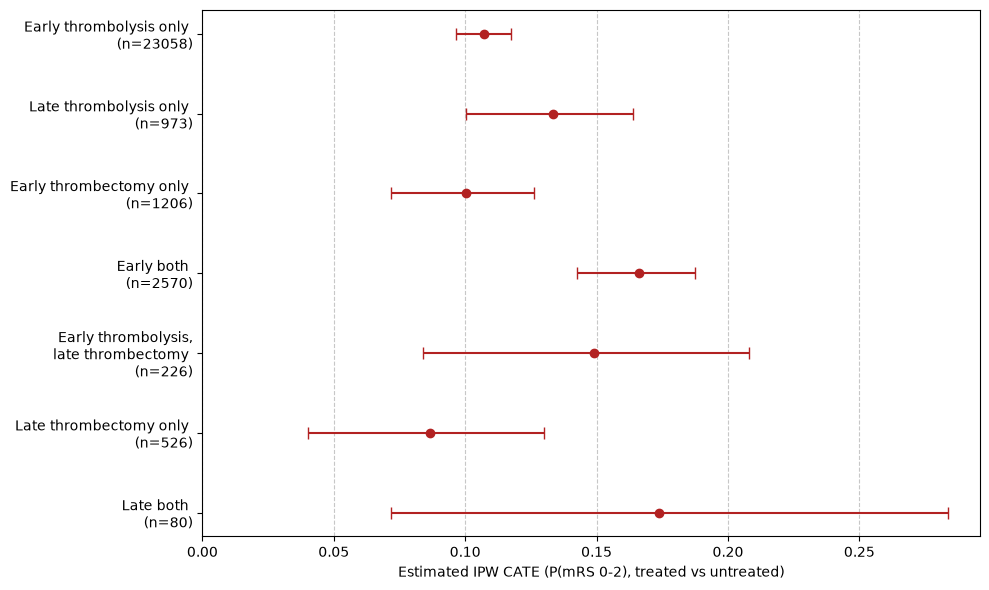

In [20]:
rename_dict = {
    "early_thrombolysis_only": "Early thrombolysis only",
    "late_thrombolysis_only": "Late thrombolysis only",
    "early_thrombectomy_only": "Early thrombectomy only",
    "late_thrombectomy_only": "Late thrombectomy only",
    "early_both": "Early both",
    "early_thrombolysis_late_thrombectomy": "Early thrombolysis,\nlate thrombectomy",
    "late_both": "Late both"
}
# Add n values to the y tick labels
n_values = ate_df["count"].astype(int).to_dict()
rename_dict = {k: f"{v} \n(n={n_values.get(k, 0)})" for k, v in rename_dict.items()}

fig, ax = plt.subplots(figsize=(10,6))
order = ate_df.index

ates = ate_df["ate"].values
lower_err = ates - ate_df["ci_lower"].values
upper_err = ate_df["ci_upper"].values - ates

y_pos = np.arange(len(order))

ax.errorbar(ates, y_pos, xerr=[lower_err, upper_err], fmt="o", color="firebrick",
            ecolor="firebrick", elinewidth=1.5, capsize=4, markersize=6)
# Add grid lines
ax.grid(axis="x", linestyle="--", alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels([rename_dict.get(label, label) for label in order])
ax.set_xlabel(f"Estimated IPW CATE (P(mRS 0-{MRS_TARGET}), treated vs untreated)")
ax.set_xlim(left=0)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"./output/ipw_cate_estimates_{MRS_TARGET}.png", dpi=300)
plt.show()


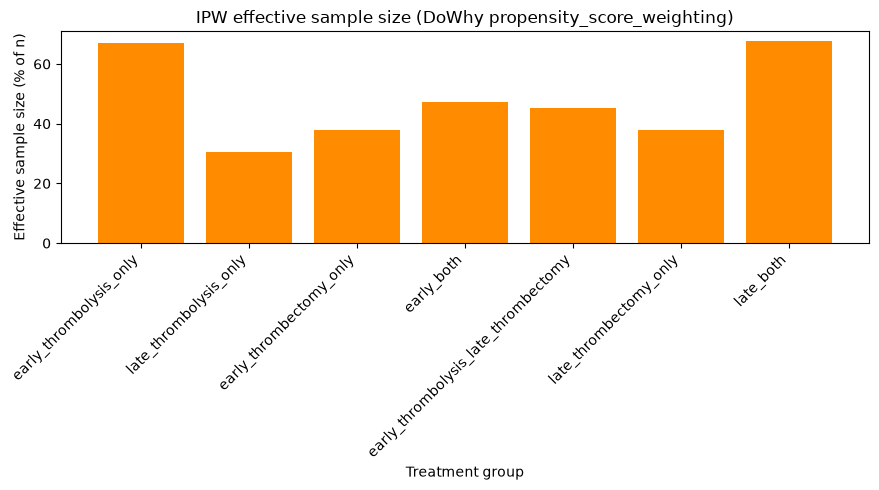

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(diagnostics_df.index, diagnostics_df["ess_pct_of_n"], color="darkorange")
ax.set_ylabel("Effective sample size (% of n)")
ax.set_xlabel("Treatment group")
ax.set_title("IPW effective sample size (DoWhy propensity_score_weighting)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


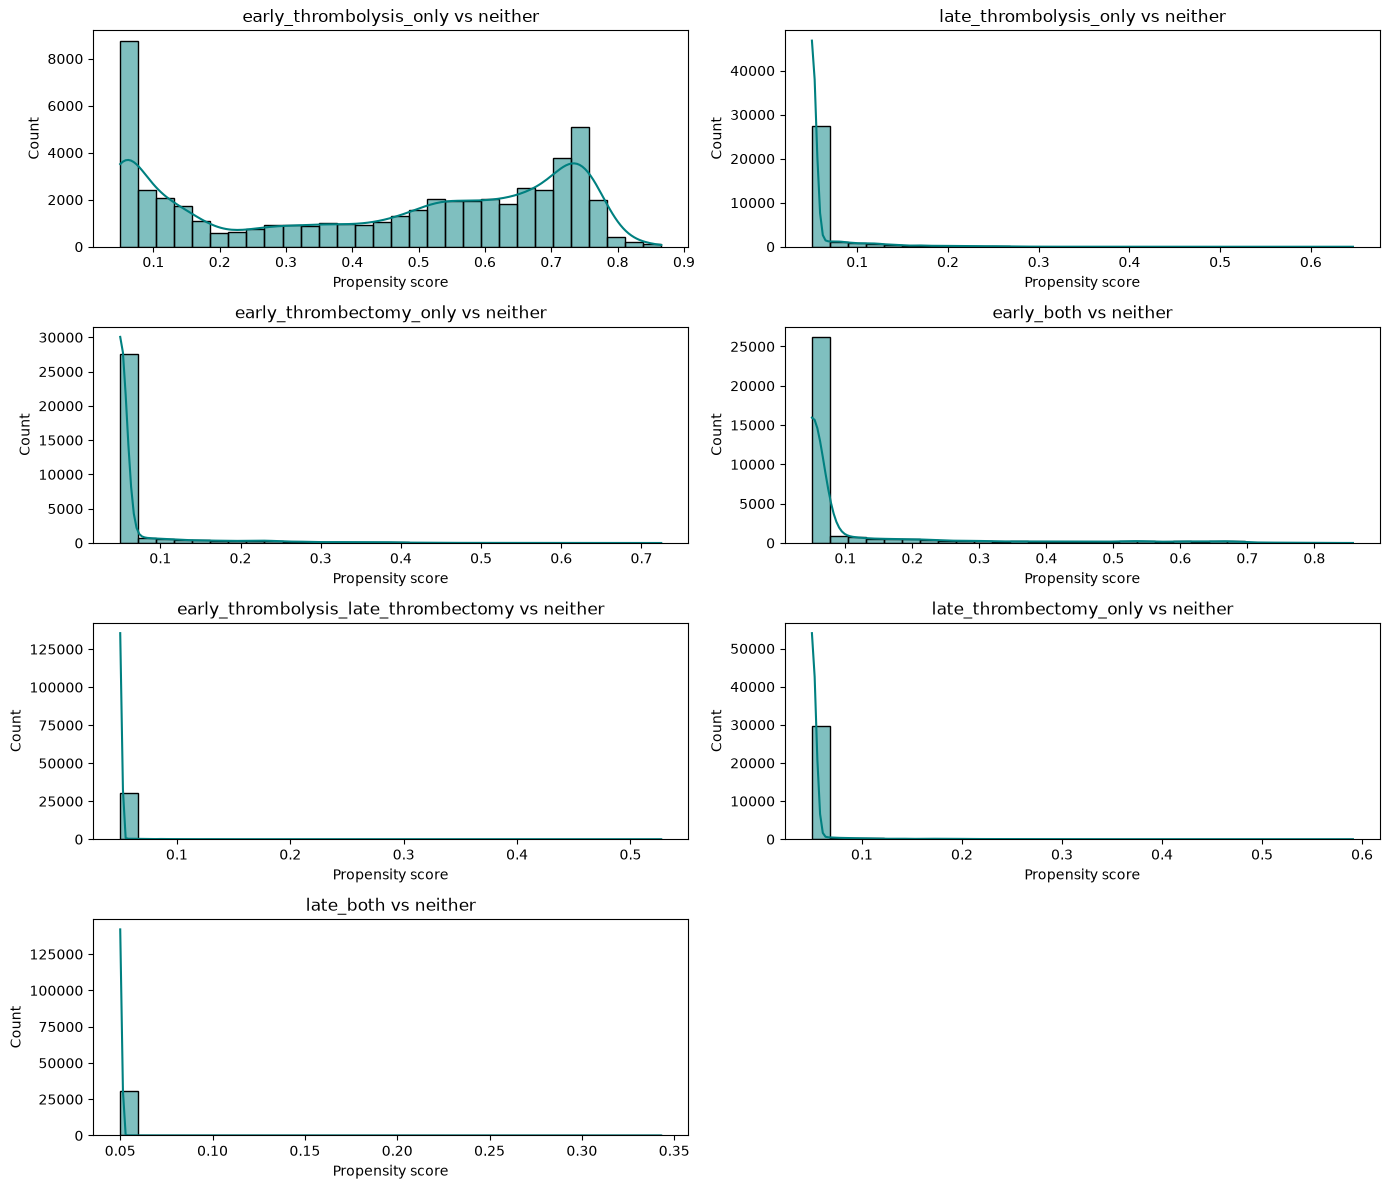

In [11]:
n_groups = len(results)
n_cols = 2
n_rows = (n_groups + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows))
axes = axes.flatten()

for ax, (group, subset) in zip(axes, results.items()):
    sns.histplot(subset["propensity_score"], bins=30, ax=ax, kde=True, color="teal")
    ax.set_title(f"{group} vs {REFERENCE_GROUP}")
    ax.set_xlabel("Propensity score")

# Hide any unused axes
for ax in axes[n_groups:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()
